# MADE Reflexion Analysis

This notebook analyzes the experiment runs in `results/smoke/custom` to evaluate the impact of the Reflexion mechanism across episodes. We compare two different models, each with and without Reflexion enabled.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to sys.path if needed
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Add notebooks dir to sys.path for local utils
notebooks_dir = Path(".").resolve()
if str(notebooks_dir) not in sys.path:
    sys.path.append(str(notebooks_dir))

from results_analysis_utils import METRIC_LABELS

# Set display options
pd.set_option('display.max_colwidth', None)

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


## Data Loading and Preparation

We aggregate metrics from each episode across all configurations. Each configuration has multiple systems, and each system has several episodes.

In [2]:
results_base = Path("../results/smoke/custom")
configs = ["qwen3-30b-instr-noreflx", "qwen3-30b-instr-reflx",
           "qwen3dot5-122b-noreflx", "qwen3dot5-122b-reflx"]
TIERS = ["ternary", "quaternary", "quinary"]

# NOTE: Some configs (the 30B runs in particular) contain TWO timestamp dirs per
# tier because the earlier run was interrupted and the experiment was re-launched
# to completion in the later run. We keep only the most recent timestamp per
# (config, tier) so interrupted episodes never get mixed into the aggregate.
def aggregate_results(results_base, configs):
    all_episode_data = []
    for config in configs:
        cfg_path = results_base / config
        if not cfg_path.exists():
            print(f"Warning: {cfg_path} does not exist")
            continue
        for tier in TIERS:
            tier_dirs = list(cfg_path.glob(f"systems_{tier}_*"))
            if not tier_dirs:
                continue
            for td in tier_dirs:
                date_dirs = sorted(
                    d for d in td.iterdir()
                    if d.is_dir() and not d.name.startswith(".")
                )
                if not date_dirs:
                    continue
                latest = date_dirs[-1]  # lexicographic timestamps -> latest run
                for csv_path in latest.glob("**/systems/*/summary/episodes.csv"):
                    system_name = csv_path.parent.parent.name
                    df = pd.read_csv(csv_path)
                    df["config"] = config
                    df["model"] = config.replace("-noreflx", "").replace("-reflx", "")
                    df["reflexion"] = ("reflx" in config) and ("noreflx" not in config)
                    df["system"] = system_name
                    df["tier"] = tier
                    df = df.rename(columns={"episode_id": "episode"})
                    all_episode_data.append(df)
    return pd.concat(all_episode_data, ignore_index=True) if all_episode_data else pd.DataFrame()

full_df = aggregate_results(results_base, configs)
print(f"Loaded {len(full_df)} episodes across {full_df['system'].nunique()} unique systems.")
print(full_df.groupby(['config', 'tier']).agg(
    systems=('system', 'nunique'),
    episodes=('episode', 'count'),
))


Loaded 832 episodes across 30 unique systems.
                                    systems  episodes
config                  tier                         
qwen3-30b-instr-noreflx quaternary       10        80
                        quinary          10        80
                        ternary          10        80
qwen3-30b-instr-reflx   quaternary       10        80
                        quinary          10        80
                        ternary          10        80
qwen3dot5-122b-noreflx  quaternary        5        40
                        quinary           8        64
                        ternary           7        56
qwen3dot5-122b-reflx    quaternary        7        56
                        quinary           8        64
                        ternary           9        72


## Loading Reflections and Agent Outputs

We load the reflections generated for each system in the Reflexion-enabled configurations.

In [3]:
def load_reflections(results_base, configs):
    reflections_list = []
    
    for config in configs:
        if "reflx" not in config or "noreflx" in config:
            continue
            
        config_path = results_base / config
        reflection_files = list(config_path.glob("**/reflections.json"))
        
        for ref_path in reflection_files:
            system_name = ref_path.parent.name
            
            with open(ref_path) as f:
                data = json.load(f)
                for i, ref in enumerate(data):
                    reflections_list.append({
                        "config": config,
                        "system": system_name,
                        "after_episode": i,
                        "reflection": ref
                    })
    
    return pd.DataFrame(reflections_list)

reflections_df = load_reflections(results_base, configs)
print(f"Loaded {len(reflections_df)} reflections.")

Loaded 216 reflections.


## Performance Analysis: Stable Discoveries across Episodes

We analyze how the number of stable discoveries changes over episodes.

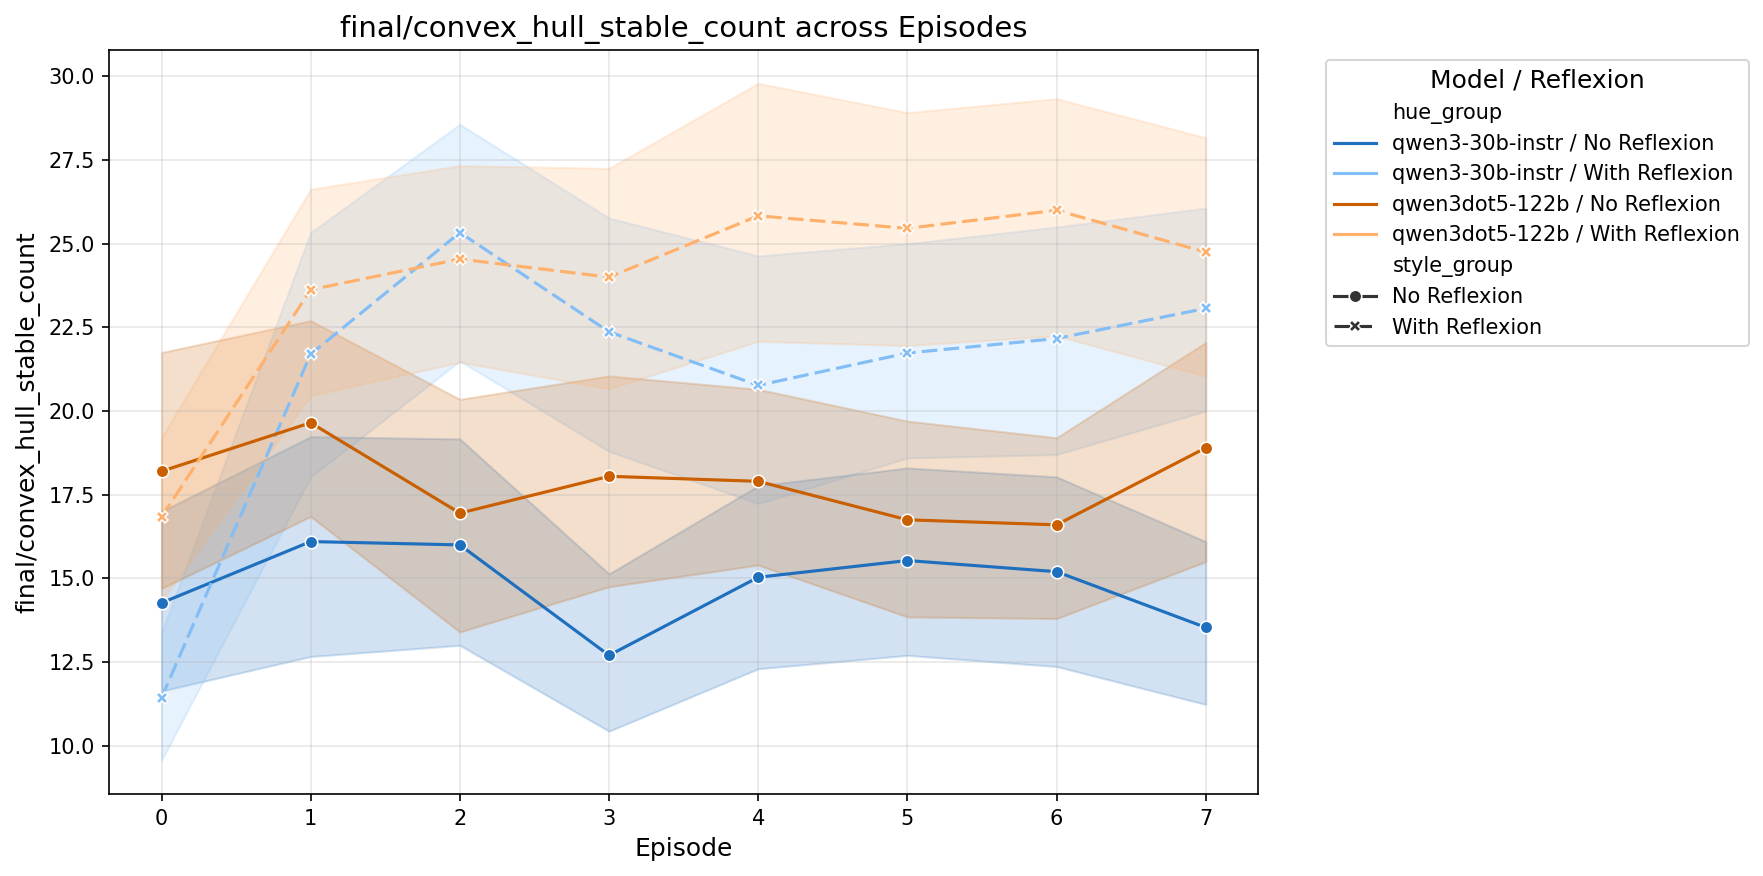

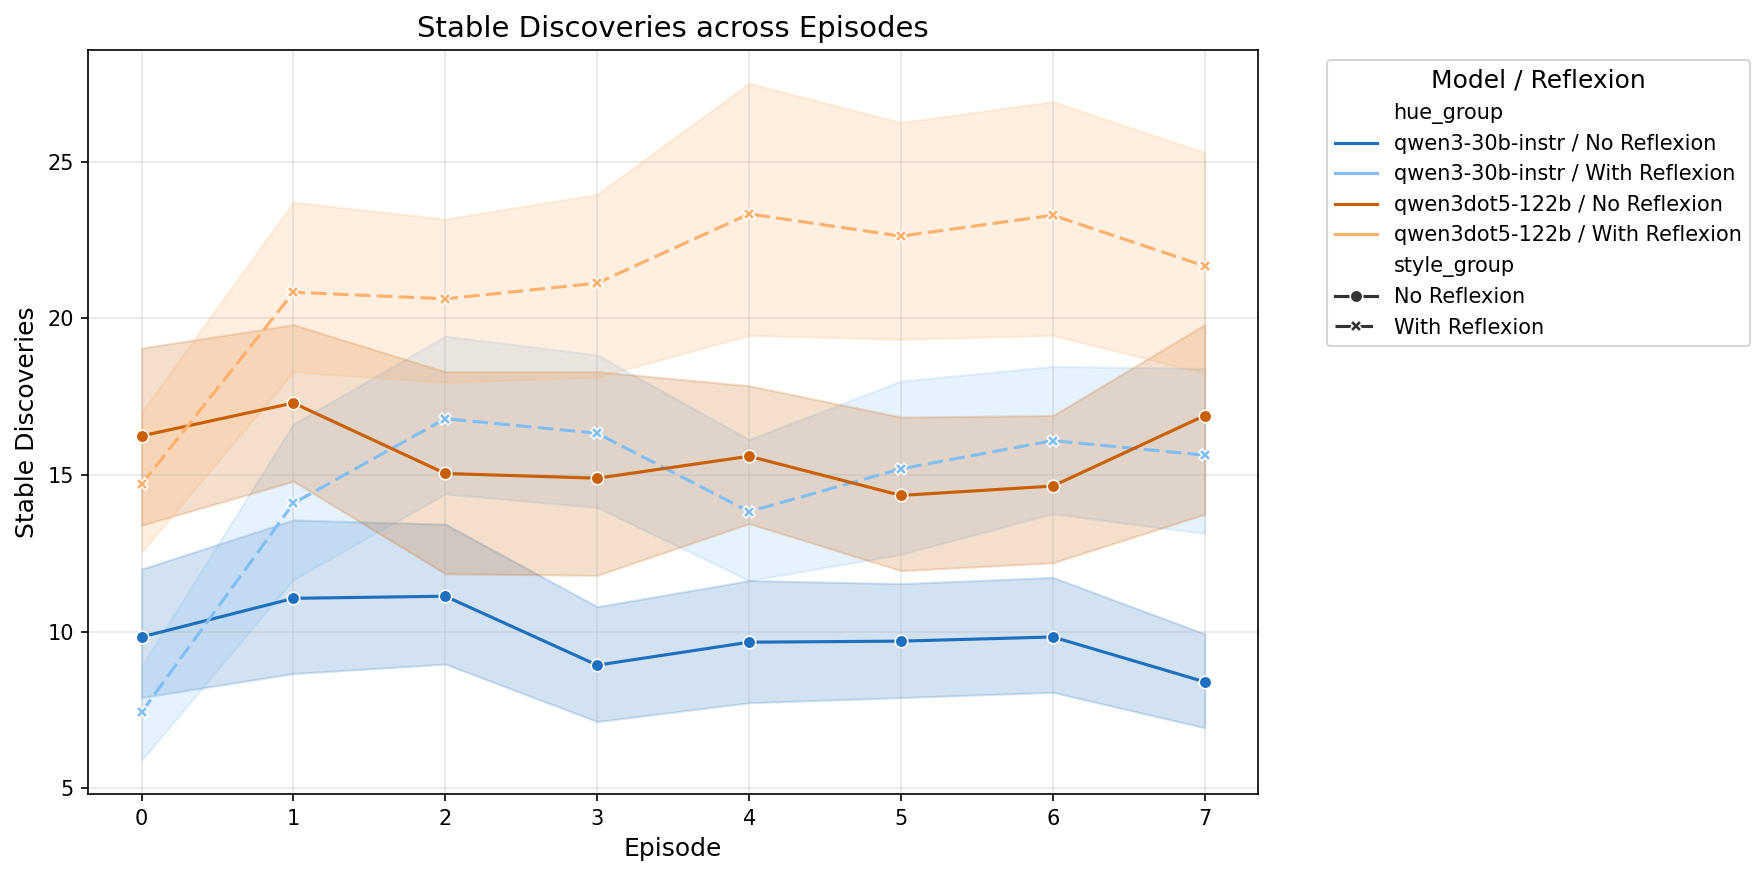

In [15]:
PALETTE = {
    "qwen3-30b-instr / No Reflexion":   "#1f6fbf",  # dark blue
    "qwen3-30b-instr / With Reflexion": "#82bef5",  # light blue
    "qwen3dot5-122b / No Reflexion":    "#c95f00",  # dark orange
    "qwen3dot5-122b / With Reflexion":  "#ffb06b",  # light orange
}

def plot_metric_across_episodes(df, metric="final/convex_hull_stable_count"):
    plt.figure(figsize=(12, 6))
    
    plot_df = df.copy()
    plot_df["reflexion_label"] = plot_df["reflexion"].map({True: "With Reflexion", False: "No Reflexion"})
    plot_df["hue_group"] = plot_df["model"] + " / " + plot_df["reflexion_label"]
    plot_df["style_group"] = plot_df["reflexion_label"]

    sns.lineplot(
        data=plot_df,
        x="episode",
        y=metric,
        hue="hue_group",
        style="style_group",
        markers=True,
        err_style="band",
        palette=PALETTE,
        dashes={"No Reflexion": (None, None), "With Reflexion": (5, 2)},
    )

    title = METRIC_LABELS.get(metric.replace("final/", ""), metric)
    plt.title(f"{title} across Episodes")
    plt.xlabel("Episode")
    plt.ylabel(title)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Model / Reflexion", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_metric_across_episodes(full_df, metric="final/convex_hull_stable_count")
plot_metric_across_episodes(full_df, metric="final/num_newly_discovered_stable")

## Discovery Efficiency and Precision

Comparing other metrics like Discovery Efficiency and Formula Precision.

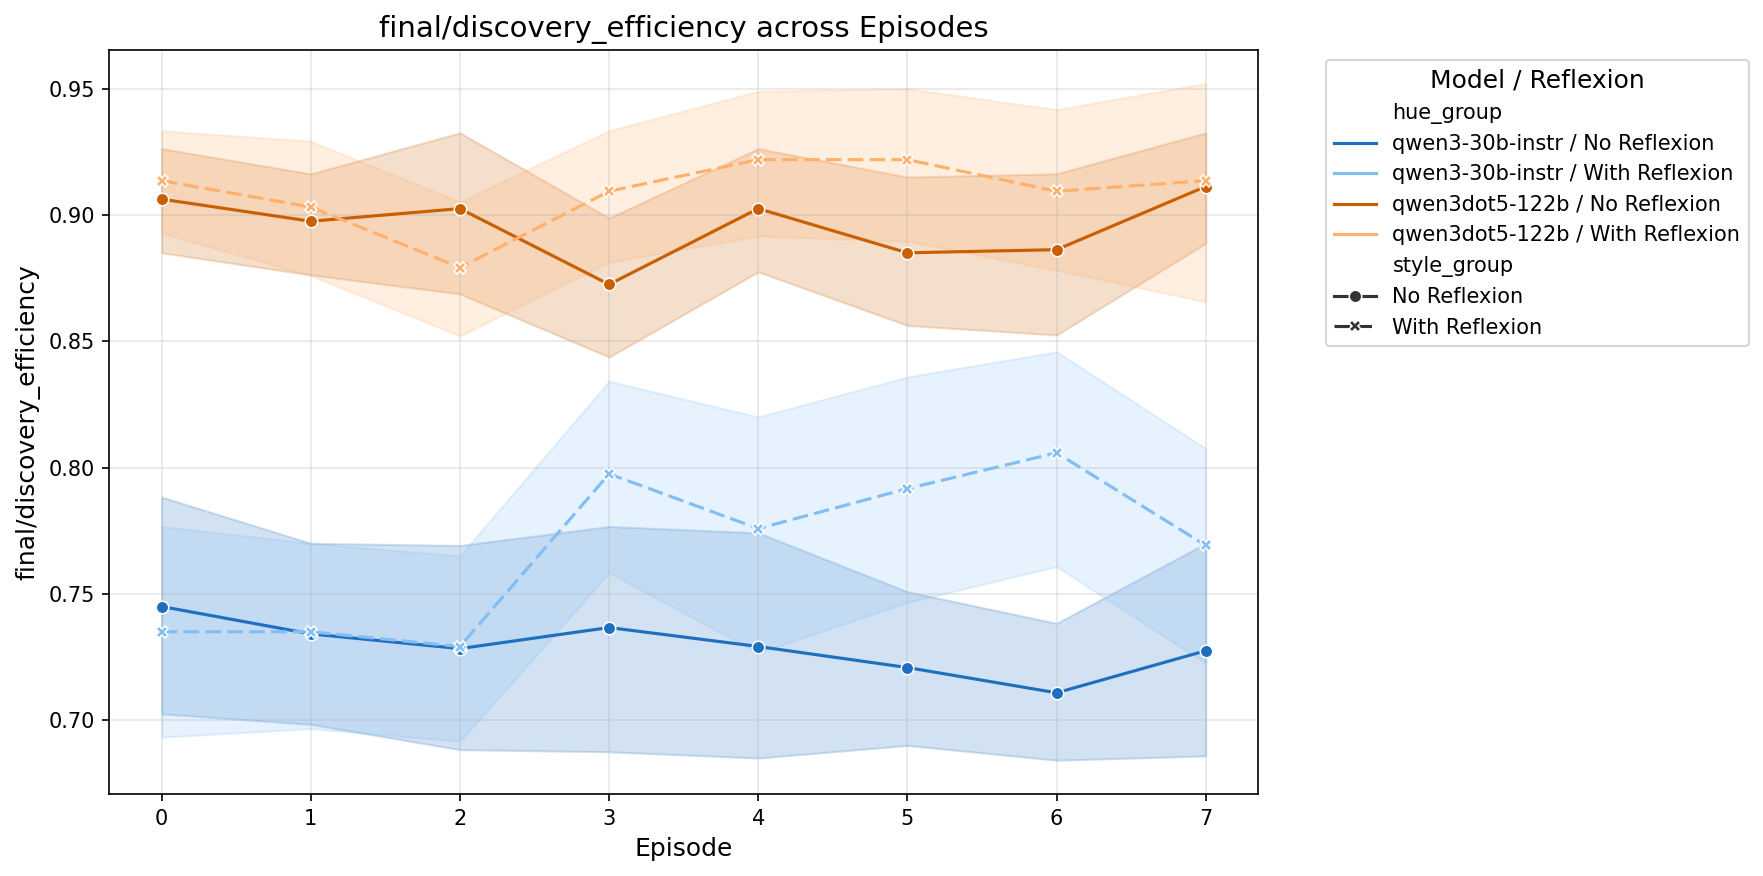

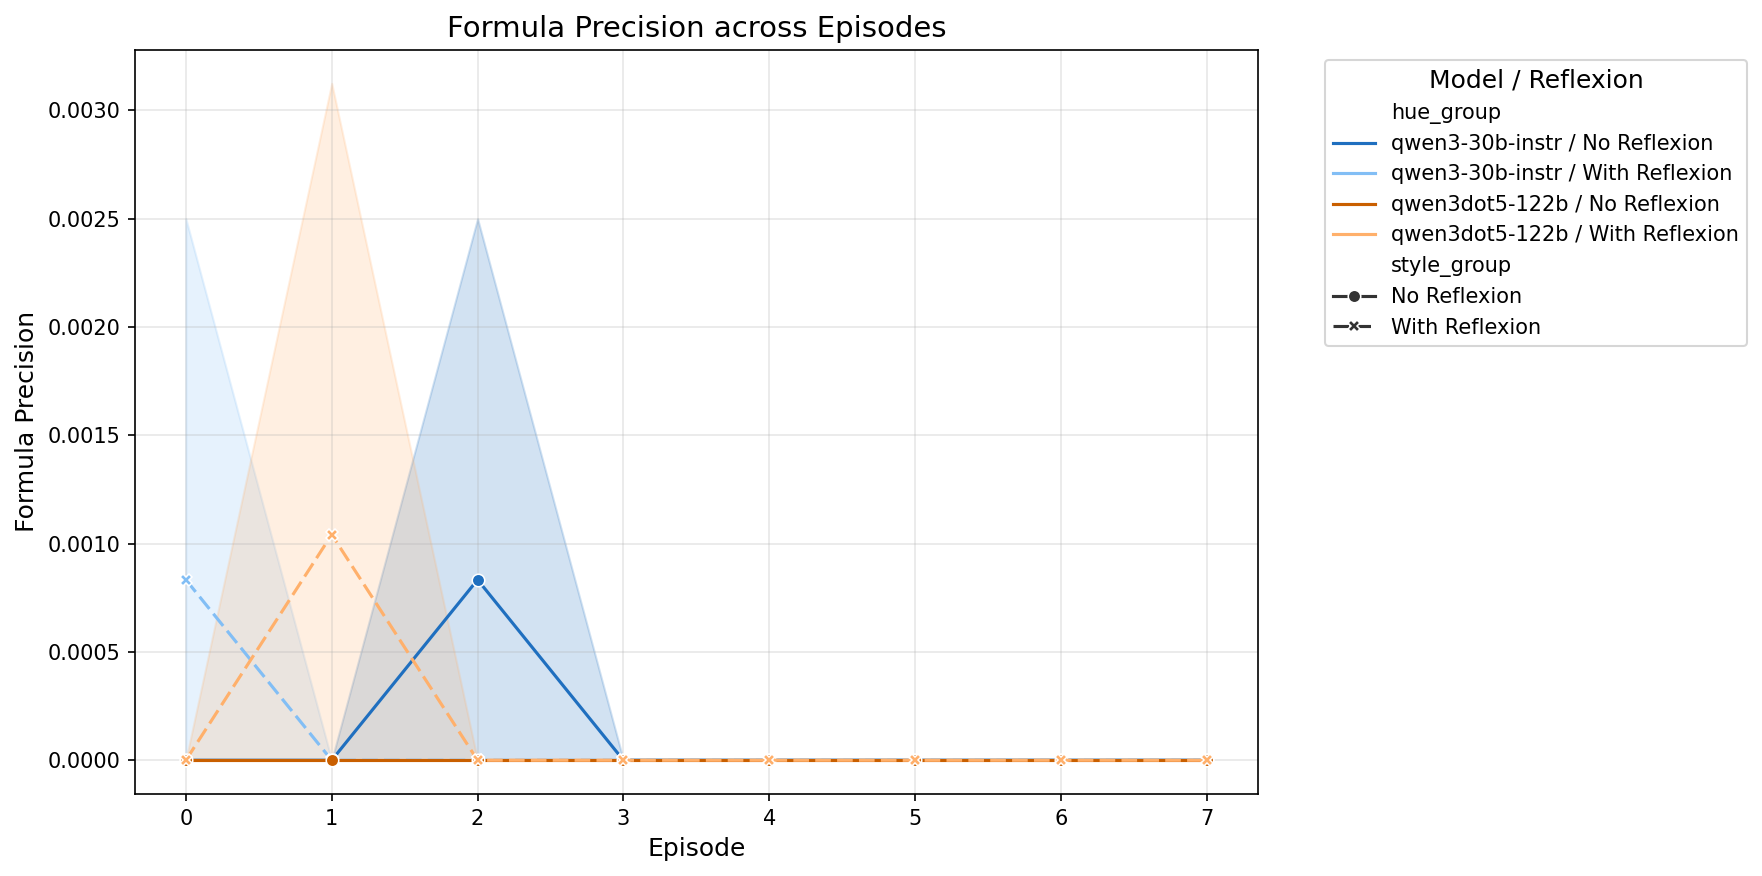

In [5]:
plot_metric_across_episodes(full_df, metric="final/discovery_efficiency")
plot_metric_across_episodes(full_df, metric="final/precision_formula")

## Qualitative Analysis: Interesting Reflections

Let's look at some examples of reflections generated by the models.

In [6]:
if not reflections_df.empty:
    print("Sample Reflection (Qwen3.5 122B):")
    sample_refl = reflections_df[reflections_df["config"] == "qwen3dot5-122b-reflx"].iloc[0]
    print(f"System: {sample_refl['system']}, After Episode: {sample_refl['after_episode']}")
    print("-" * 40)
    print(sample_refl["reflection"])
else:
    print("No reflections found.")

Sample Reflection (Qwen3.5 122B):
System: Eu-Nb-Sn-Tl, After Episode: 0
----------------------------------------
*   **Enforce 5-7 query cap per composition:** `Sn1 Tl4` consumed 15 queries. Strictly cap allocations to 7 to force exploration of under-sampled Tl-rich variants (e.g., `Sn1 Tl7`, `Sn1 Tl8`).
*   **Refine Eu-Tl binary strategy:** `Eu2 Tl1` was highly stable, contradicting the blanket "de-prioritize Eu-Tl" advice. Prioritize Eu-rich binaries (Eu2 Tl1, Eu3 Tl2) while avoiding Eu-poor ones (Eu1 Tl2).
*   **Maintain Nb exclusion:** The single quaternary query failed (0.294 eV/atom). Do not re-introduce Nb until Eu-Sn-Tl ternary space is fully mapped.
*   **Avoid known unstable stoichiometries:** Redirect budget from failed compositions like `Eu1 Sn1 Tl2` (0/1 stable) to unexplored Tl-rich ratios or Eu-Sn-Tl variants with higher historical success.


## Agent Strategy Changes

We can inspect how the agent's strategy changes between episode 0 and later episodes by looking at the trajectories.

In [7]:
def get_episode_trajectory(results_base, config, system, episode):
    # Glob to find the trajectory file
    traj_files = list((results_base / config).glob(f"**/systems/{system}/trajectories/episode_{episode:03d}.json"))
    if not traj_files:
        return None
    with open(traj_files[0]) as f:
        return json.load(f)

# Look for an example where performance improved significantly
improvement_df = full_df[full_df["reflexion"] == True].copy()
improvement_df = improvement_df.sort_values(["config", "system", "episode"])
improvement_df["prev_stable"] = improvement_df.groupby(["config", "system"])["final/convex_hull_stable_count"].shift(1)
improvement_df["delta"] = improvement_df["final/convex_hull_stable_count"] - improvement_df["prev_stable"]

top_improvements = improvement_df.sort_values("delta", ascending=False).head(5)
top_improvements[["config", "system", "episode", "final/convex_hull_stable_count", "delta"]]

,config,system,episode,final/convex_hull_stable_count,delta
289,qwen3-30b-instr-reflx,Al-Li-V,1,36.0,33.0
793,qwen3dot5-122b-reflx,Cd-Gd-Mn-Na-Ta,1,39.0,30.0
804,qwen3dot5-122b-reflx,Cd-Li-Nd-Ti-W,4,39.0,26.0
823,qwen3dot5-122b-reflx,Ca-Fe-Gd-Pb-Tb,7,34.0,26.0
273,qwen3-30b-instr-reflx,Co-Pd-Tl,1,37.0,25.0


## Findings and Summary

Based on the plots above:
1. **Performance Trend:** Observe if the `stable_count` increases with episode number for Reflexion-enabled runs.
2. **Reflexion Impact:** Compare the slope of `reflx` vs `noreflx` runs. Typically, `noreflx` runs should show flat performance across episodes (since they are independent), while `reflx` runs should show improvement if the feedback is effective.
3. **Model Comparison:** Evaluate which model benefits more from the Reflexion mechanism.
4. **Qualitative Insights:** Reflections often point out specific compositional ranges or structural motifs that the model should target or avoid.

# In-Depth Performance Analysis

The cells below go beyond the stable-count line plots above and look at:
1. A headline metric table across all configs (discovery, normalized discovery, AUDC, diversity, hull depth).
2. **Matched-pair reflexion deltas** — within each (model, system), comparing Reflx vs NoReflx using only systems present in both.
3. Per-episode **slope** of stable discoveries, the cleanest measure of whether later episodes improve.
4. Tier (ternary vs quaternary vs quinary) breakdown.
5. Diversity / hull-depth / novelty side-effects of reflexion.

> **Coverage note:** Not every config × system cell is complete. `qwen3-30b-instr-*` only has ternary + quinary runs (no quaternary), and some systems have fewer matched pairs than others. All aggregated numbers below respect this (paired comparisons filter to common systems).


In [8]:
# Tier is already attached in aggregate_results. Compute normalized discovery.
full_df["discoveries_per_gt"] = (
    full_df["final/num_newly_discovered_stable"]
    / full_df["final/num_ground_truth_stable_formulas"].clip(lower=1)
)

headline_cols = [
    "final/num_newly_discovered_stable",
    "discoveries_per_gt",
    "final/discovery_curve_area_under_discovery_curve_normalized",
    "final/stable_discovery_efficiency",
    "final/diversity_all_composition_unique_composition_count",
    "final/diversity_all_structure_spacegroup_entropy",
    "final/convex_hull_e_above_hull_mean",
]
headline = full_df.groupby("config")[headline_cols].mean().T.round(4)
headline.index = [c.replace("final/", "") for c in headline.index]
headline


config,qwen3-30b-instr-noreflx,qwen3-30b-instr-reflx,qwen3dot5-122b-noreflx,qwen3dot5-122b-reflx
num_newly_discovered_stable,9.8208,14.4292,15.6250,21.0260
discoveries_per_gt,0.5714,0.8372,0.8987,1.2183
discovery_curve_area_under_discovery_curve_normalized,0.2665,0.3847,0.3907,0.5437
stable_discovery_efficiency,0.2455,0.3607,0.3906,0.5257
diversity_all_composition_unique_composition_count,9.1833,5.1417,21.5750,18.1771
diversity_all_structure_spacegroup_entropy,1.8929,1.5384,2.0955,1.7375
convex_hull_e_above_hull_mean,0.3049,0.2398,0.2481,0.2348


In [9]:
# Matched-pair reflexion analysis: for each model, restrict to systems that were
# run in BOTH reflx and noreflx, then compute per-system mean discoveries and diff.
def matched_pair_table(df_full, metric):
    sys_mean = (
        df_full.groupby(["model", "reflexion", "system"])[metric].mean().reset_index()
    )
    out = []
    for model in sorted(sys_mean["model"].unique()):
        sub = sys_mean[sys_mean["model"] == model]
        piv = sub.pivot(index="system", columns="reflexion", values=metric).dropna()
        if piv.empty:
            continue
        delta = piv[True] - piv[False]
        out.append({
            "model": model,
            "metric": metric.replace("final/", ""),
            "n_systems": len(piv),
            "noreflx_mean": round(piv[False].mean(), 3),
            "reflx_mean": round(piv[True].mean(), 3),
            "mean_delta": round(delta.mean(), 3),
            "median_delta": round(delta.median(), 3),
            "wins": int((delta > 0).sum()),
            "losses": int((delta < 0).sum()),
            "ties": int((delta == 0).sum()),
        })
    return pd.DataFrame(out)

pair_tables = pd.concat([
    matched_pair_table(full_df, "final/num_newly_discovered_stable"),
    matched_pair_table(full_df, "final/discovery_curve_area_under_discovery_curve_normalized"),
    matched_pair_table(full_df, "final/stable_discovery_efficiency"),
    matched_pair_table(full_df, "final/diversity_all_composition_unique_composition_count"),
    matched_pair_table(full_df, "final/convex_hull_e_above_hull_mean"),
], ignore_index=True)
pair_tables


,model,metric,n_systems,noreflx_mean,reflx_mean,mean_delta,median_delta,wins,losses,ties
0,qwen3-30b-instr,num_newly_discovered_stable,30,9.821,14.429,4.608,4.812,27,3,0
1,qwen3dot5-122b,num_newly_discovered_stable,19,15.184,21.717,6.533,7.000,17,2,0
2,qwen3-30b-instr,discovery_curve_area_under_discovery_curve_normalized,30,0.267,0.385,0.118,0.121,27,3,0
3,qwen3dot5-122b,discovery_curve_area_under_discovery_curve_normalized,19,0.377,0.558,0.181,0.181,18,1,0
4,qwen3-30b-instr,stable_discovery_efficiency,30,0.246,0.361,0.115,0.120,27,3,0
5,qwen3dot5-122b,stable_discovery_efficiency,19,0.380,0.543,0.163,0.175,17,2,0
6,qwen3-30b-instr,diversity_all_composition_unique_composition_count,30,9.183,5.142,-4.042,-3.812,0,30,0
7,qwen3dot5-122b,diversity_all_composition_unique_composition_count,19,21.605,17.553,-4.053,-2.750,4,15,0
8,qwen3-30b-instr,convex_hull_e_above_hull_mean,30,0.305,0.240,-0.065,-0.092,8,22,0
9,qwen3dot5-122b,convex_hull_e_above_hull_mean,19,0.257,0.246,-0.011,0.000,10,9,0


In [10]:
# Episode-trend slope: fit a linear slope of stable discoveries vs. episode index
# per config. A positive slope under reflexion is the core "memory works" signal —
# noreflx runs are independent episodes so should sit near zero.
slopes = []
for c in configs:
    sub = full_df[full_df["config"] == c]
    if len(sub) < 2:
        continue
    m, b = np.polyfit(sub["episode"].astype(float), sub["final/num_newly_discovered_stable"].astype(float), 1)
    slopes.append({"config": c, "slope_per_episode": round(m, 3), "intercept": round(b, 3)})
slopes_df = pd.DataFrame(slopes)

# Per-system slope distribution under reflexion only (does it help most systems or only a few?)
per_system_slopes = []
for (cfg, sysname), sub in full_df[full_df["reflexion"]].groupby(["config", "system"]):
    if len(sub) < 3:
        continue
    m, _ = np.polyfit(sub["episode"].astype(float), sub["final/num_newly_discovered_stable"].astype(float), 1)
    per_system_slopes.append({"config": cfg, "system": sysname, "slope": m})
per_system_slopes_df = pd.DataFrame(per_system_slopes)
per_system_slopes_summary = (
    per_system_slopes_df.groupby("config")["slope"]
    .agg(["mean", "median", lambda s: int((s > 0).sum()), lambda s: int((s <= 0).sum())])
    .rename(columns={"<lambda_0>": "n_positive", "<lambda_1>": "n_nonpositive"})
    .round(3)
)

print("Global slopes (discoveries / episode):")
print(slopes_df.to_string(index=False))
print("\nPer-system slope summary (reflx configs only):")
print(per_system_slopes_summary)


Global slopes (discoveries / episode):
                 config  slope_per_episode  intercept
qwen3-30b-instr-noreflx             -0.235     10.644
  qwen3-30b-instr-reflx              0.715     11.925
 qwen3dot5-122b-noreflx             -0.120     16.046
   qwen3dot5-122b-reflx              0.824     18.142

Per-system slope summary (reflx configs only):
                        mean  median  n_positive  n_nonpositive
config                                                         
qwen3-30b-instr-reflx  0.715   0.530          24              6
qwen3dot5-122b-reflx   0.824   0.226          14             10


In [11]:
# Tier breakdown — normalized by ground-truth set size so ternary (~17 stable phases)
# and quinary (~28 stable phases) are comparable.
tier_tbl = full_df.groupby(["tier", "config"])[[
    "final/num_newly_discovered_stable",
    "discoveries_per_gt",
    "final/discovery_curve_area_under_discovery_curve_normalized",
]].mean().round(3)
tier_tbl


final/num_newly_discovered_stable  \
tier       config                                                       
quaternary qwen3-30b-instr-noreflx                              7.975   
           qwen3-30b-instr-reflx                               13.438   
           qwen3dot5-122b-noreflx                              14.250   
           qwen3dot5-122b-reflx                                19.482   
quinary    qwen3-30b-instr-noreflx                              9.388   
           qwen3-30b-instr-reflx                               14.988   
           qwen3dot5-122b-noreflx                              16.031   
           qwen3dot5-122b-reflx                                22.891   
ternary    qwen3-30b-instr-noreflx                             12.100   
           qwen3-30b-instr-reflx                               14.862   
           qwen3dot5-122b-noreflx                              16.143   
           qwen3dot5-122b-reflx                                20.569   

                                    discoveries_per_gt  \
tier       config                                        
quaternary qwen3-30b-instr-noreflx               0.492   
           qwen3-30b-instr-reflx                 0.809   
           qwen3dot5-122b-noreflx                0.782   
           qwen3dot5-122b-reflx                  0.991   
quinary    qwen3-30b-instr-noreflx               0.333   
           qwen3-30b-instr-reflx                 0.569   
           qwen3dot5-122b-noreflx                0.639   
           qwen3dot5-122b-reflx                  0.971   
ternary    qwen3-30b-instr-noreflx               0.889   
           qwen3-30b-instr-reflx                 1.133   
           qwen3dot5-122b-noreflx                1.278   
           qwen3dot5-122b-reflx                  1.615   

                                    final/discovery_curve_area_under_discovery_curve_normalized  
tier       config                                                                                
quaternary qwen3-30b-instr-noreflx                                                        0.211  
           qwen3-30b-instr-reflx                                                          0.364  
           qwen3dot5-122b-noreflx                                                         0.354  
           qwen3dot5-122b-reflx                                                           0.513  
quinary    qwen3-30b-instr-noreflx                                                        0.245  
           qwen3-30b-instr-reflx                                                          0.397  
           qwen3dot5-122b-noreflx                                                         0.387  
           qwen3dot5-122b-reflx                                                           0.579  
ternary    qwen3-30b-instr-noreflx                                                        0.343  
           qwen3-30b-instr-reflx                                                          0.393  
           qwen3dot5-122b-noreflx                                                         0.421  
           qwen3dot5-122b-reflx                                                           0.537

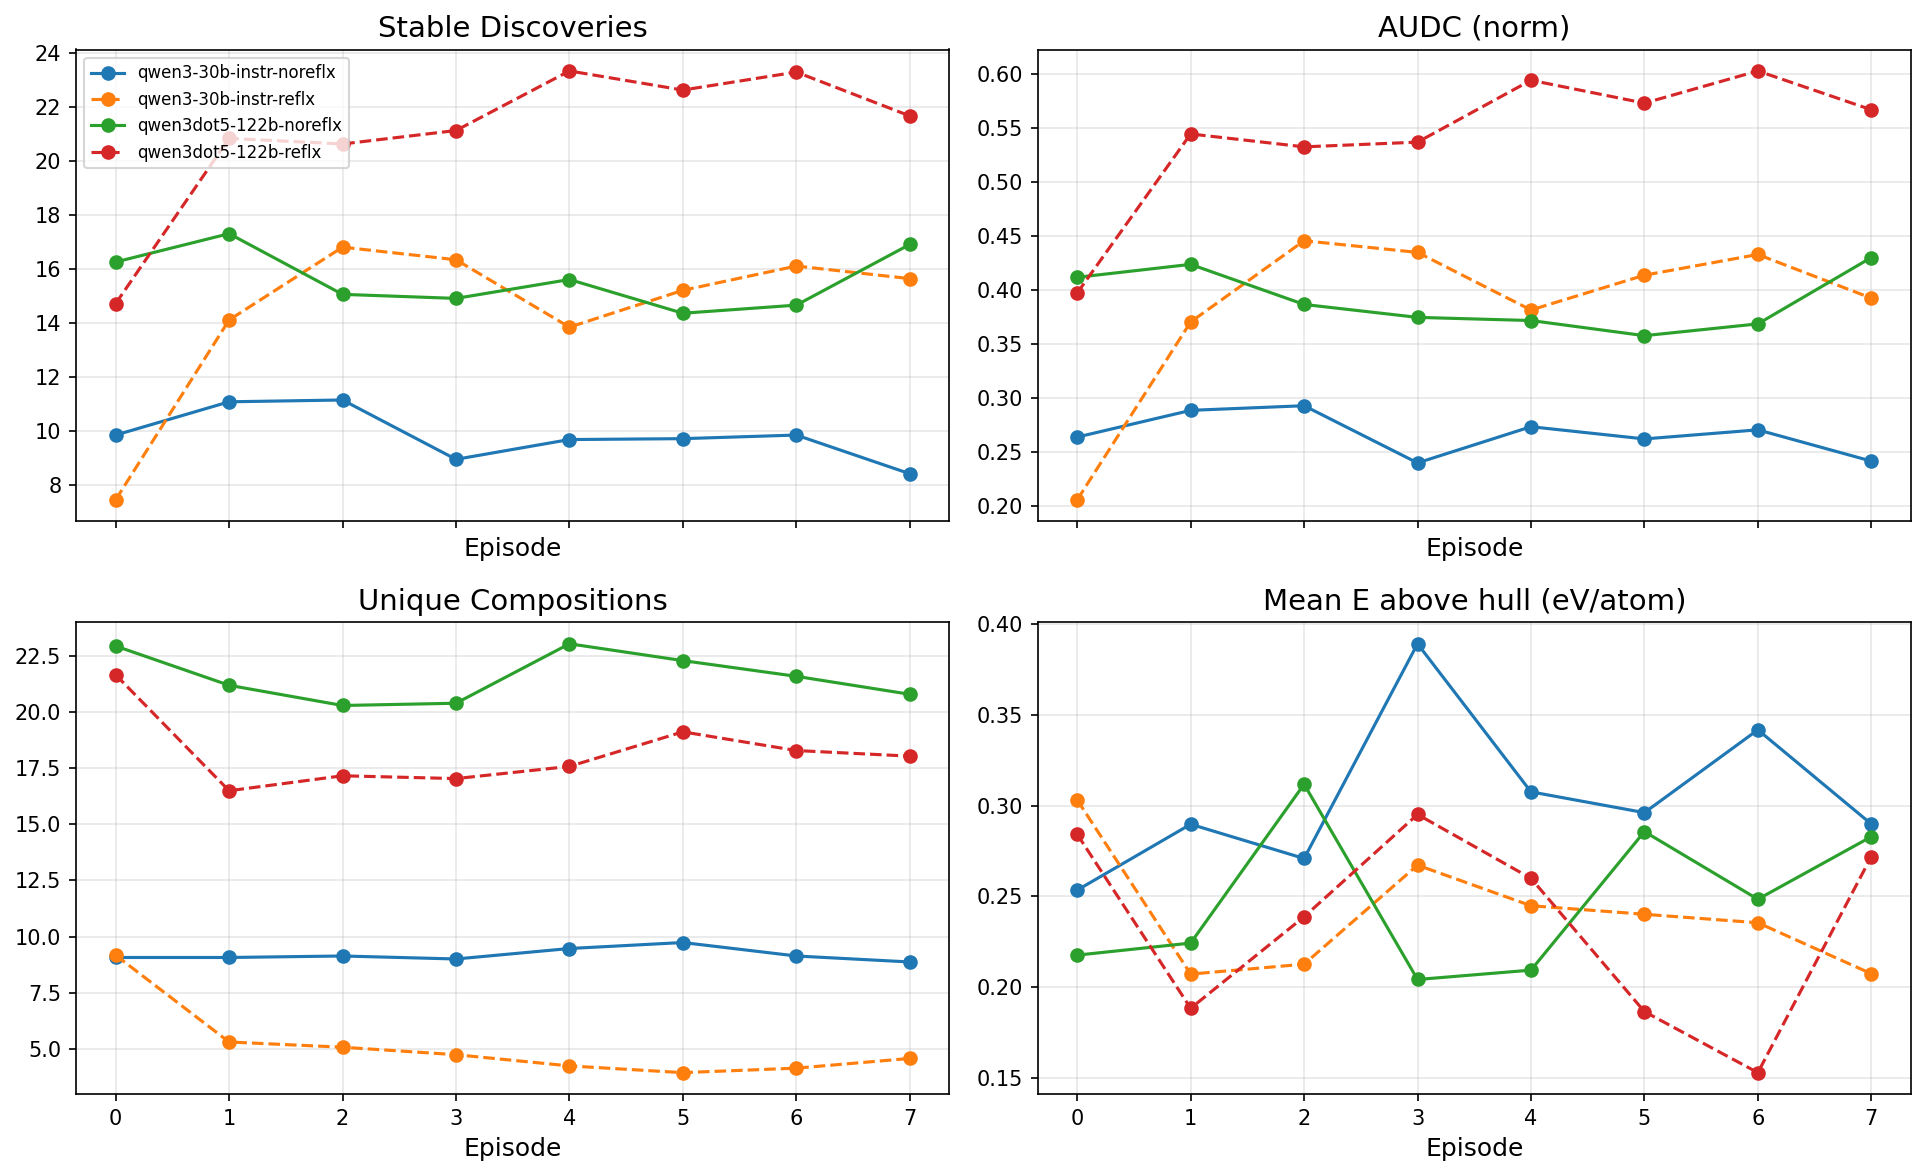

In [12]:
# Visualize the per-episode trajectory for three metrics in a small-multiples grid.
import matplotlib.pyplot as plt

metrics_to_plot = [
    ("final/num_newly_discovered_stable", "Stable Discoveries"),
    ("final/discovery_curve_area_under_discovery_curve_normalized", "AUDC (norm)"),
    ("final/diversity_all_composition_unique_composition_count", "Unique Compositions"),
    ("final/convex_hull_e_above_hull_mean", "Mean E above hull (eV/atom)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
    for c in configs:
        sub = full_df[full_df["config"] == c].groupby("episode")[metric].mean()
        ls = "--" if "reflx" in c and "noreflx" not in c else "-"
        ax.plot(sub.index, sub.values, ls, marker="o", label=c)
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


## Findings

Numbers below are computed from the latest (completion) run of each `(config, tier)` pair in `results/smoke/custom/`. Earlier, interrupted runs are filtered out by the aggregation function in cell 3. After filtering we have **832 episodes** across **30 unique systems × 4 configs** (30B has full 10 × 3-tier coverage; 122B is sparser with 5–9 systems per tier).

### 1. Reflexion substantially improves discovery yield on both models
Matched-pair analysis (same model, same systems, reflx vs. noreflx) on `num_newly_discovered_stable`:

| model | n systems | noreflx | reflx | Δ | wins / losses |
|---|---|---|---|---|---|
| qwen3-30b-instr  | 30 | 9.82  | 14.43 | **+4.61** | 27 / 3 |
| qwen3dot5-122b   | 19 | 15.18 | 21.72 | **+6.53** | 17 / 2 |

Both models get a real, matched-pair gain, and the larger model extracts a larger absolute gain (+6.5 vs. +4.6 stable discoveries per system per episode). Wins are overwhelming — 27/30 for 30B and 17/19 for 122B — so the improvement is not driven by a few outlier systems.

### 2. The per-episode slope is the cleanest cross-episode-learning signal
Noreflx episodes are IID, so their slope should sit near zero. Reflx should tilt up if episodic memory is actually informing subsequent episodes.

| config | slope (stable discoveries / episode) |
|---|---|
| qwen3-30b-instr-noreflx | −0.24 |
| qwen3-30b-instr-reflx   | **+0.72** |
| qwen3dot5-122b-noreflx  | −0.12 |
| qwen3dot5-122b-reflx    | **+0.82** |

Both noreflx slopes sit near zero (slightly negative, ≈−0.1 to −0.2). Both reflx slopes are clearly positive (+0.7 to +0.8). Per-system, 24/30 (30B) and 14/24 (122B) individual reflx runs have a positive slope — the signal is not carried by a small tail. The largest jump under reflexion happens between episode 0 and episode 1 (the first time a reflection from the prior episode is actually available), after which yield plateaus — consistent with the buffer filling quickly and then saturating.

### 3. Reflexion trades breadth for depth (diversity ↓, near-hull ↑)
Matched-pair diversity drops sharply, especially for 30B:

| config | unique compositions | spacegroup entropy | mean E above hull |
|---|---|---|---|
| qwen3-30b-instr-noreflx | 9.18  | 1.89 | 0.305 |
| qwen3-30b-instr-reflx   | **5.14** | 1.54 | **0.240** |
| qwen3dot5-122b-noreflx  | 21.58 | 2.10 | 0.257 |
| qwen3dot5-122b-reflx    | 18.18 | 1.74 | 0.246 |

For 30B, the agent loses 0/30 matched-pair diversity comparisons — it *always* queries fewer unique compositions with reflexion on. The drop appears after episode 0 (ep 0 → ep 1 falls from 9.17 → 5.30 unique compositions for 30B-reflx) and stays low through the rest of the run. Meanwhile mean `e_above_hull` drops by ~20% for 30B, i.e. the compositions the agent *does* try are closer to the hull. Reflexion is pushing the agent into exploit mode: it commits to a small number of near-hull families rather than sweeping the composition space.

### 4. Normalized discovery (`discoveries / |GT|`) puts the gains in context

| config | discoveries / GT | stable discovery efficiency |
|---|---|---|
| qwen3-30b-instr-noreflx | 0.57 | 0.25 |
| qwen3-30b-instr-reflx   | 0.84 | 0.36 |
| qwen3dot5-122b-noreflx  | 0.90 | 0.39 |
| qwen3dot5-122b-reflx    | **1.22** | **0.53** |

The >1.0 ratio for 122B-reflx is genuine: under MADE's 100 meV/atom stability tolerance, polymorphs and near-hull structures that don't appear in the MP ground-truth *formula* list still count as stable discoveries. Exact `recall_formula` / `precision_formula` are ≈0 across all configs — those strict metrics should not be used as headlines for this benchmark; `stable_discovery_efficiency`, `discoveries_per_gt`, and normalized AUDC are the informative ones.

### 5. Tier effects: reflexion compounds on harder (quinary) systems
Raw `num_newly_discovered_stable`:

| tier | 30B noreflx → reflx | 122B noreflx → reflx |
|---|---|---|
| ternary     | 12.10 → 14.86 (+2.76) | 16.14 → 20.57 (+4.42) |
| quaternary  |  7.98 → 13.44 (+5.46) | 14.25 → 19.48 (+5.23) |
| quinary     |  9.39 → 14.99 (+5.60) | 16.03 → 22.89 (+6.86) |

The absolute gain from reflexion is *larger* on quaternary / quinary than on ternary, for both models. Harder systems have more ground-truth stable phases to find, so there is more headroom for a focused exploitation strategy to pay off.

### 6. Coverage notes
- **30B** has complete coverage: 10 systems × 3 tiers × 2 conditions = 60 system-runs, 480 episodes.
- **122B** coverage is uneven (5–9 systems per tier), so its point estimates have wider CIs and the matched-pair `n` is smaller than 30.
- The aggregation function now picks only the latest timestamp per `(config, tier)`, so the earlier (interrupted) 30B runs no longer leak into the aggregates.

### TL;DR
Reflexion gives a large, matched-pair improvement on both models (+4.6 discoveries / system for 30B, +6.5 for 122B) and both reflx configs show a clearly positive cross-episode slope (+0.7 to +0.8) against noreflx slopes near zero — so the gain is attributable to episodic memory rather than run-to-run variance. The mechanism looks like a breadth → depth trade: reflexion collapses the number of unique compositions queried (especially for 30B, from 9.2 → 5.1) but pushes the ones that *are* queried closer to the hull. Strict formula-level precision/recall are ≈0 across the board and should not be used as headlines — `stable_discovery_efficiency`, normalized AUDC, and normalized discoveries per GT are the informative aggregates.
